# Altitude-constrained 3D trilateration demo

This notebook demonstrates the MVP solver: three GPS-good anchors provide latitude, longitude, altitude, and 3D TWR range; the GPS-denied target provides its own altitude.

In [8]:
from pathlib import Path

from IPython.display import Image, display
from trilateration import Anchor, geodetic_to_ecef, solve_position
from trilateration.visualization import plot_solution
import numpy as np

target = (50.4529, 30.5268, 183.5)
anchor_coords = [
    ('A', 50.4401, 30.5234, 180.0),
    ('B', 50.4565, 30.5201, 190.0),
    ('C', 50.4510, 30.5340, 175.0),
]

def range_m(anchor):
    _, lat, lon, alt = anchor
    return float(np.linalg.norm(geodetic_to_ecef(lat, lon, alt) - geodetic_to_ecef(*target)))

anchors = [
    Anchor(lat_deg=lat, lon_deg=lon, alt_m=alt, distance_m=range_m(anchor), node_id=node_id)
    for anchor, (node_id, lat, lon, alt) in zip(anchor_coords, anchor_coords)
]
exact_result = solve_position(anchors, target_alt_m=target[2])
exact_result.to_dict()

{'lat_deg': 50.4529,
 'lon_deg': 30.52680000000001,
 'alt_m': 183.5,
 'residuals_m': [{'anchor': 'A',
   'expected_distance_m': 1444.2228977945445,
   'observed_distance_m': 1444.2228977945445,
   'residual_m': 0.0},
  {'anchor': 'B',
   'expected_distance_m': 621.9571290990954,
   'observed_distance_m': 621.9571290990954,
   'residual_m': 0.0},
  {'anchor': 'C',
   'expected_distance_m': 553.3913539405108,
   'observed_distance_m': 553.3913539405108,
   'residual_m': 0.0}],
 'rms_error_m': 0.0,
 'max_abs_error_m': 0.0,
 'converged': True,
 'iterations': 3,
 'geometry_condition': 1.8030432267369996,
 'message': '`gtol` termination condition is satisfied.'}

## Visual check

The left plot is the top-down position check. The right plot shows altitude and vertical deltas.

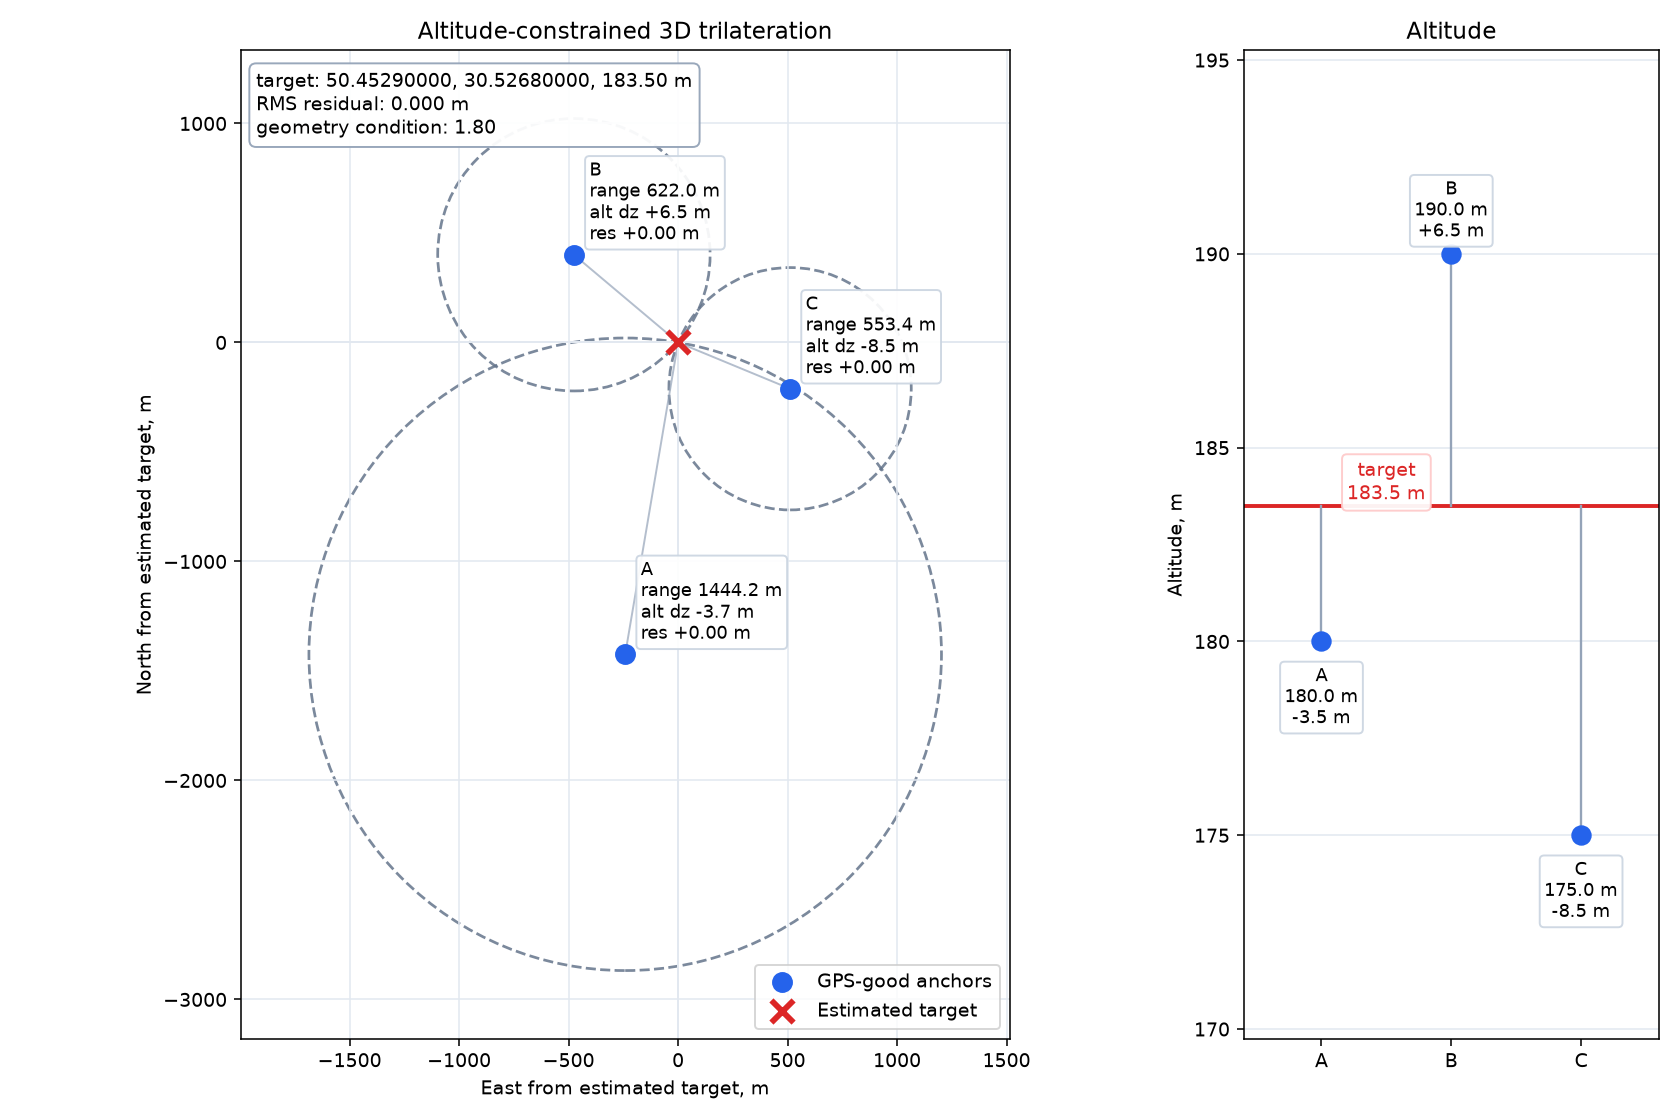

In [9]:
project_root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
plot_path = project_root / 'examples' / 'anchors_plot_from_notebook.png'
plot_solution(anchors, exact_result, plot_path)
display(Image(filename=str(plot_path)))

In [5]:
noisy_anchors = [
    Anchor(a.lat_deg, a.lon_deg, a.alt_m, a.distance_m + noise, a.node_id)
    for a, noise in zip(anchors, [1.2, -0.8, 0.5])
]
solve_position(noisy_anchors, target_alt_m=target[2]).to_dict()

{'lat_deg': 50.452912814106654,
 'lon_deg': 30.52680136959495,
 'alt_m': 183.5,
 'residuals_m': [{'anchor': 'A',
   'expected_distance_m': 395.32161602994023,
   'observed_distance_m': 395.3347351919918,
   'residual_m': -0.01311916205156649},
  {'anchor': 'B',
   'expected_distance_m': 621.1147389262139,
   'observed_distance_m': 621.1571290990954,
   'residual_m': -0.04239017288148261},
  {'anchor': 'C',
   'expected_distance_m': 553.8474855800898,
   'observed_distance_m': 553.8913539405108,
   'residual_m': -0.043868360421015495}],
 'rms_error_m': 0.03602532542478677,
 'max_abs_error_m': 0.043868360421015495,
 'converged': True,
 'iterations': 4,
 'geometry_condition': 2.0880653375977474,
 'message': '`xtol` termination condition is satisfied.'}